# 02 · Win Rate Driver Analysis

> **Audience**: CRO, VP Sales  
> **Purpose**: Diagnose exactly *why* win rate changed between the 2023 baseline and 2024-Q1, with statistical validation and business-ready recommendations.

---

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
})
WON_CLR='#16A34A'; LOST_CLR='#DC2626'; PALETTE=['#2563EB','#DC2626','#16A34A','#D97706','#7C3AED']
FIG_DIR='../outputs/figures'

from src.feature_engineering import build_engineered_dataset
df = build_engineered_dataset(save=False)
print(f"✓ {len(df):,} deals loaded | Periods: {df['period'].value_counts().to_dict()}")


[data_loader] Loaded 5,000 rows, 45.3% win rate
✓ 5,000 deals loaded | Periods: {'2023': 4039, '2024Q1': 961}


## Step 1 · Cohort Overview: Before vs After

COHORT WIN RATE COMPARISON
  Baseline (2023):   45.6%
  Current (2024-Q1): 43.6%
  Absolute change:   -2.1pp
  Relative change:   -4.5%


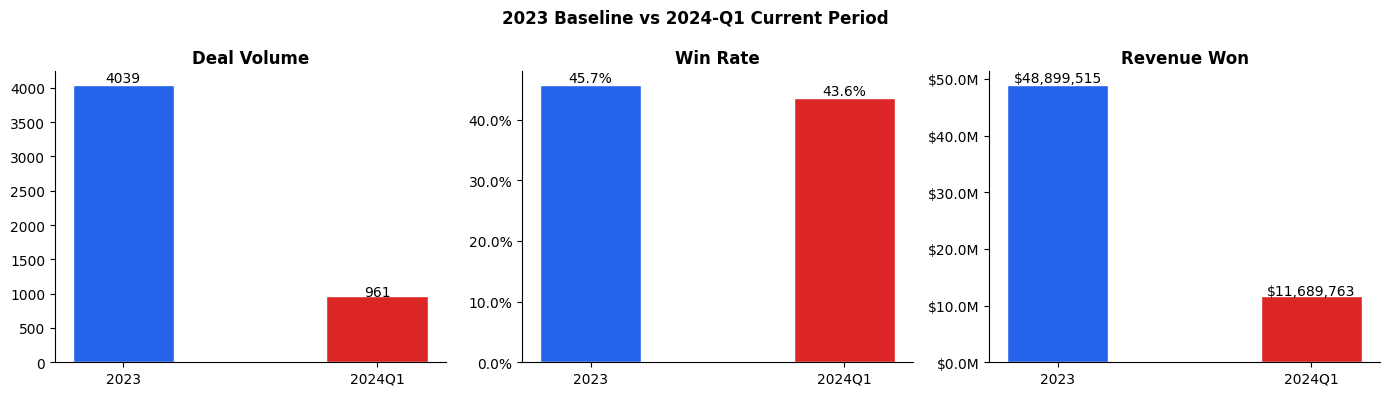

In [2]:
from src.win_rate_analyzer import cohort_win_rates

cohort = cohort_win_rates(df)
print("=" * 45)
print("COHORT WIN RATE COMPARISON")
print("=" * 45)
print(f"  Baseline (2023):   {cohort['baseline_wr']:.1%}")
print(f"  Current (2024-Q1): {cohort['current_wr']:.1%}")
print(f"  Absolute change:   {cohort['absolute_change']*100:+.1f}pp")
print(f"  Relative change:   {cohort['relative_change']*100:+.1f}%")

# ── Cohort volume + WR side-by-side ──────────────────────────
period_stats = df.groupby('period').agg(
    deals=('won','count'), win_rate=('won','mean'),
    total_revenue=('deal_amount', lambda x: x[df.loc[x.index,'won']==1].sum()),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, fmt, title in zip(
    axes,
    ['deals','win_rate','total_revenue'],
    ['{:.0f}','{:.1%}','${:,.0f}'],
    ['Deal Volume','Win Rate','Revenue Won'],
):
    vals = period_stats.set_index('period')[col]
    colors = [PALETTE[0], PALETTE[1]]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', width=0.4)
    ax.set_title(title, fontweight='bold')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                fmt.format(v), ha='center', fontsize=10)
    if col == 'win_rate':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    elif col == 'total_revenue':
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

plt.suptitle('2023 Baseline vs 2024-Q1 Current Period', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/10_cohort_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 2 · Segment Decomposition

For each dimension, we compare win rate, volume, and revenue impact between the two periods. Results are ranked by **business impact score** (not just win rate delta) so the CRO focuses on what matters most financially.

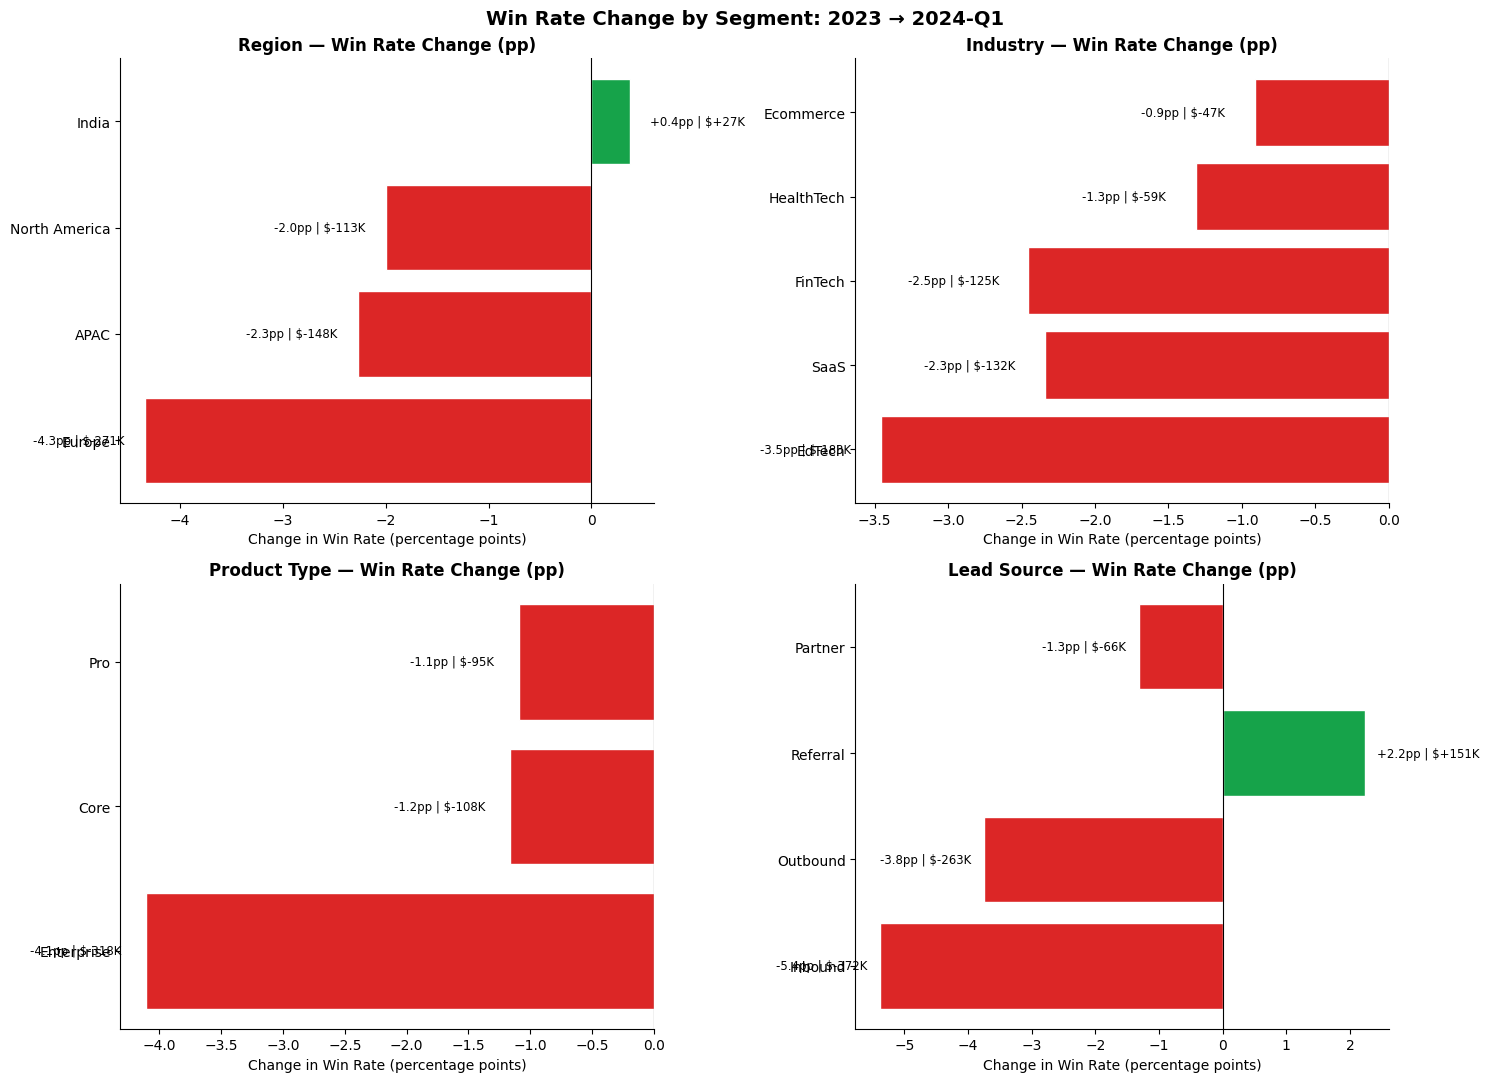

In [3]:
from src.win_rate_analyzer import segment_decomposition

DIMS = ['region', 'industry', 'product_type', 'lead_source']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for ax, dim in zip(axes.flatten(), DIMS):
    seg = segment_decomposition(df, dim)

    # Plot WR change as horizontal bars coloured by direction
    colors = [WON_CLR if v > 0 else LOST_CLR for v in seg['wr_change']]
    bars = ax.barh(seg['segment'], seg['wr_change'] * 100, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{dim.replace("_"," ").title()} — Win Rate Change (pp)', fontweight='bold')
    ax.set_xlabel('Change in Win Rate (percentage points)')
    for bar, (_, row) in zip(bars, seg.iterrows()):
        x = bar.get_width()
        label = f"{row['wr_change']*100:+.1f}pp | ${row['revenue_impact']/1000:+.0f}K"
        ax.text(x + (0.2 if x >= 0 else -0.2), bar.get_y() + bar.get_height()/2,
                label, va='center', ha='left' if x >= 0 else 'right', fontsize=8.5)

plt.suptitle('Win Rate Change by Segment: 2023 → 2024-Q1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/11_segment_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
# Print detailed tables for each dimension
for dim in DIMS:
    seg = segment_decomposition(df, dim)
    print(f"\n{'='*60}")
    print(f"  {dim.upper()} BREAKDOWN")
    print(f"{'='*60}")
    display_cols = ['segment','deals_base','win_rate_base','deals_curr','win_rate_curr',
                    'wr_change','revenue_impact','business_impact_score']
    print(seg[display_cols].to_string(index=False, float_format=lambda x: f'{x:.3f}'))



  REGION BREAKDOWN
      segment  deals_base  win_rate_base  deals_curr  win_rate_curr  wr_change  revenue_impact  business_impact_score
       Europe        1000          0.464         233          0.421     -0.043     -270724.713                270.725
         APAC        1003          0.454         239          0.431     -0.023     -148059.971                148.060
North America         989          0.452         250          0.432     -0.020     -113388.343                113.388
        India        1047          0.457         239          0.460      0.004       26825.917                 26.826

  INDUSTRY BREAKDOWN
   segment  deals_base  win_rate_base  deals_curr  win_rate_curr  wr_change  revenue_impact  business_impact_score
    EdTech         801          0.448         191          0.414     -0.035     -183086.398                183.086
      SaaS         800          0.456         201          0.433     -0.023     -132205.797                132.206
   FinTech         749 

## Step 3 · Statistical Significance Testing

Before drawing conclusions, we test whether observed win rate changes are statistically significant or just noise. Uses chi-square test on Win/Loss counts. Only significant results (p < 0.05) drive recommendations.

In [5]:
from src.win_rate_analyzer import test_significance

print("Statistically significant win rate changes (p < 0.05):")
print("=" * 60)
for dim in DIMS:
    sig = test_significance(df, dim)
    sig_only = sig[sig['is_significant']]
    if len(sig_only):
        print(f"\n{dim.upper()}:")
        print(sig_only[['segment','base_wr','curr_wr','p_value','base_n','curr_n']].to_string(index=False))
    else:
        print(f"\n{dim.upper()}: No statistically significant changes detected.")


Statistically significant win rate changes (p < 0.05):



REGION: No statistically significant changes detected.

INDUSTRY: No statistically significant changes detected.

PRODUCT_TYPE: No statistically significant changes detected.

LEAD_SOURCE: No statistically significant changes detected.


## Step 4 · Simpson's Paradox Check ✦

**This is the most important analytical step.**

The overall win rate change has two possible sources:
- **Conversion effect**: We're selling worse in the same segments (fix: coaching, process)
- **Mix shift effect**: We changed what deals we pursue (fix: targeting, SDR strategy)

Conflating these leads to **wrong interventions**. The Kitagawa-Oaxaca-Blinder decomposition separates them precisely.

In [6]:
from src.win_rate_analyzer import simpsons_paradox_check

print("SIMPSONS PARADOX / MIX SHIFT DECOMPOSITION")
print("=" * 60)
for dim in ['region', 'industry', 'product_type', 'lead_source']:
    sp = simpsons_paradox_check(df, dim)
    mix_pct = sp['mix_share_of_change'] * 100
    print(f"\n{dim.upper()}:")
    print(f"  Total WR change:      {sp['total_wr_change']*100:+.2f}pp")
    print(f"  Conversion effect:    {sp['conversion_effect']*100:+.2f}pp  ({100-mix_pct:.0f}%)")
    print(f"  Mix shift effect:     {sp['mix_shift_effect']*100:+.2f}pp  ({mix_pct:.0f}%)")
    if mix_pct > 25:
        print(f"  ⚠️  Mix shift explains {mix_pct:.0f}% of change — TARGETING issue, not sales execution")
    else:
        print(f"  ✓  Change is primarily conversion-driven — sales execution is the lever")


SIMPSONS PARADOX / MIX SHIFT DECOMPOSITION

REGION:
  Total WR change:      -2.05pp
  Conversion effect:    -2.04pp  (99%)
  Mix shift effect:     -0.01pp  (1%)
  ✓  Change is primarily conversion-driven — sales execution is the lever

INDUSTRY:
  Total WR change:      -2.05pp
  Conversion effect:    -2.10pp  (98%)
  Mix shift effect:     +0.04pp  (2%)
  ✓  Change is primarily conversion-driven — sales execution is the lever

PRODUCT_TYPE:
  Total WR change:      -2.05pp
  Conversion effect:    -2.05pp  (100%)
  Mix shift effect:     -0.00pp  (0%)
  ✓  Change is primarily conversion-driven — sales execution is the lever

LEAD_SOURCE:
  Total WR change:      -2.05pp
  Conversion effect:    -2.14pp  (96%)
  Mix shift effect:     +0.09pp  (4%)
  ✓  Change is primarily conversion-driven — sales execution is the lever


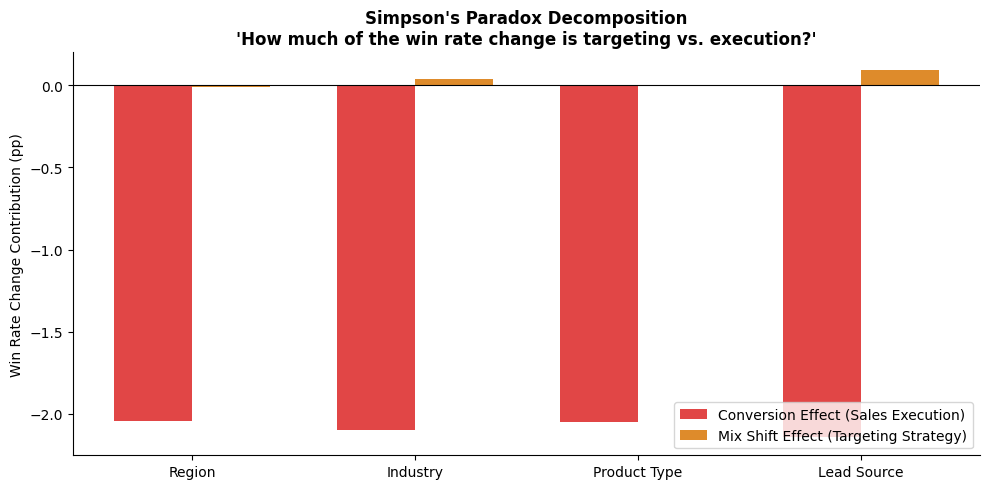

In [7]:
# Visualise the decomposition
dims = ['region', 'industry', 'product_type', 'lead_source']
decomp_data = []
for dim in dims:
    sp = simpsons_paradox_check(df, dim)
    decomp_data.append({
        'dimension': dim,
        'conversion_effect': sp['conversion_effect'] * 100,
        'mix_shift_effect': sp['mix_shift_effect'] * 100,
    })

decomp_df = pd.DataFrame(decomp_data)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(dims))
w = 0.35
ax.bar([i - w/2 for i in x], decomp_df['conversion_effect'], width=w,
       label='Conversion Effect (Sales Execution)', color=LOST_CLR, alpha=0.85)
ax.bar([i + w/2 for i in x], decomp_df['mix_shift_effect'], width=w,
       label='Mix Shift Effect (Targeting Strategy)', color=PALETTE[3], alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([d.replace('_',' ').title() for d in dims])
ax.set_ylabel('Win Rate Change Contribution (pp)')
ax.set_title("Simpson's Paradox Decomposition\n'How much of the win rate change is targeting vs. execution?'", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/12_simpsons_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5 · Feature Importance Model

FEATURE IMPORTANCE (Logistic Regression Coefficients)
         feature  coefficient  abs_importance          direction
sales_cycle_days    -0.032959        0.032959 Decreases Win Rate
     deal_amount     0.032684        0.032684 Increases Win Rate
     lead_source    -0.013781        0.013781 Decreases Win Rate
        industry     0.006119        0.006119 Increases Win Rate
    product_type    -0.003661        0.003661 Decreases Win Rate
          region    -0.000670        0.000670 Decreases Win Rate


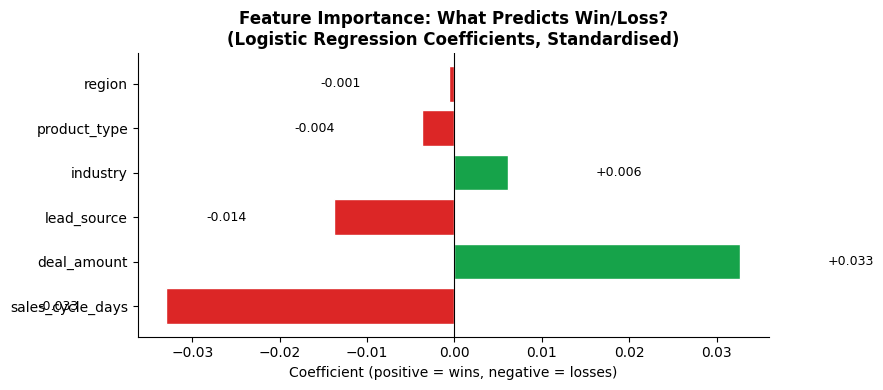

In [8]:
from src.win_rate_analyzer import feature_importance_model

importance = feature_importance_model(df)
print("FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("=" * 55)
print(importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = [WON_CLR if d == 'Increases Win Rate' else LOST_CLR for d in importance['direction']]
bars = ax.barh(importance['feature'], importance['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Importance: What Predicts Win/Loss?\n(Logistic Regression Coefficients, Standardised)', fontweight='bold')
ax.set_xlabel('Coefficient (positive = wins, negative = losses)')
for bar, (_, row) in zip(bars, importance.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.01 if x >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"{x:+.3f}", va='center', ha='left' if x >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 6 · Root Cause Narrative & Recommendations

Synthesising all analyses above into the CRO's answer.

In [9]:
from src.win_rate_analyzer import generate_insights, segment_decomposition, cohort_win_rates

cohort = cohort_win_rates(df)
insights = generate_insights(df)

print("=" * 65)
print("EXECUTIVE SUMMARY: WIN RATE DRIVER ANALYSIS")
print("=" * 65)
chg = cohort['absolute_change'] * 100
print("SITUATION")
print("---------")
print(f"Win rate shifted from {cohort['baseline_wr']:.1%} (2023 baseline) to")
print(f"{cohort['current_wr']:.1%} (2024-Q1) - a {chg:+.1f}pp change.")
print()
print("FINDINGS")
print("--------")
for i, insight in enumerate(insights, 1):
    print(f"  {i}. {insight}")

print()
print("RECOMMENDED ACTIONS")
print("-------------------")
print("  1. Run the Simpsons Paradox results past the SDR/marketing team:")
print("     if mix-shift is the dominant driver, change ICP targeting first.")
print("  2. For conversion-driven drops: identify which specific rep +")
print("     segment combinations are underperforming and prioritise coaching.")
print("  3. Review lead source quality -- if Referral premium is decaying,")
print("     investigate the referral partner programme.")
print("  4. Set up the 5-metric alert system (see Notebook 03) to catch")
print("     future declines 6-8 weeks earlier.")


EXECUTIVE SUMMARY: WIN RATE DRIVER ANALYSIS
SITUATION
---------
Win rate shifted from 45.6% (2023 baseline) to
43.6% (2024-Q1) - a -2.1pp change.

FINDINGS
--------
  1. Overall win rate changed from 45.6% (2023 baseline) to 43.6% (2024-Q1), a shift of -2.1 percentage points.
  2. 'Europe' (region) showed the largest win-rate decline: -4.3pp, representing an estimated $270,725 revenue impact.
  3. 'EdTech' (industry) showed the largest win-rate decline: -3.5pp, representing an estimated $183,086 revenue impact.
  4. 'Enterprise' (product_type) showed the largest win-rate decline: -4.1pp, representing an estimated $318,291 revenue impact.
  5. 'Inbound' (lead_source) showed the largest win-rate decline: -5.4pp, representing an estimated $372,059 revenue impact.

RECOMMENDED ACTIONS
-------------------
  1. Run the Simpsons Paradox results past the SDR/marketing team:
     if mix-shift is the dominant driver, change ICP targeting first.
  2. For conversion-driven drops: identify which sp

## Step 7 · AI-Generated Executive Narrative

The analysis above produces numbers. A CRO needs a story.

We pass the pre-computed results — cohort win rates, segment changes, Simpson's decomposition, feature importances — to a LLaMA 3.3 70B model (via Groq) with a strict system prompt that instructs it to **only reference numbers from the provided context and never hallucinate figures**.

If no `GROQ_API_KEY` is set in `.env`, a clean templated fallback is used automatically.

In [10]:
from src.win_rate_analyzer import (
    cohort_win_rates, segment_decomposition, simpsons_paradox_check,
    feature_importance_model, generate_insights
)
from src.insight_narrator import generate_executive_narrative
import os

# ── Assemble analysis context ────────────────────────────────
cohort   = cohort_win_rates(df)
insights = generate_insights(df)

# Top segment changes across all dimensions ranked by revenue impact
all_segs = []
for dim in ['region','industry','product_type','lead_source']:
    seg = segment_decomposition(df, dim)
    for _, row in seg.iterrows():
        all_segs.append({
            'dimension':      dim,
            'segment':        row['segment'],
            'wr_change':      row['wr_change'],
            'revenue_impact': row['revenue_impact'],
        })
all_segs.sort(key=lambda x: abs(x['revenue_impact']), reverse=True)

# Simpson's decomposition for each dimension
simpsons_all = {}
for dim in ['region','industry','product_type','lead_source']:
    sp = simpsons_paradox_check(df, dim)
    simpsons_all[dim] = {
        'conversion_effect': sp['conversion_effect'],
        'mix_shift_effect':  sp['mix_shift_effect'],
    }

importance = feature_importance_model(df)
feat_records = importance[['feature','coefficient','direction']].to_dict('records')

analysis_context = {
    'cohort':                  cohort,
    'top_segment_changes':     all_segs[:6],
    'simpsons':                simpsons_all,
    'feature_importance':      feat_records,
    'programmatic_insights':   insights,
}

# ── Generate narrative ───────────────────────────────────────
print("Generating executive narrative...")
narrative = generate_executive_narrative(analysis_context)

print()
print("=" * 65)
print("AI-GENERATED EXECUTIVE NARRATIVE")
print("=" * 65)
print(narrative)

# Store for use in Notebook 03 report builder
import json, os
os.makedirs('../outputs/reports', exist_ok=True)
with open('../outputs/reports/analysis_context.json', 'w') as f:
    # Serialise — convert numpy types
    ctx_serialisable = {
        'cohort': {k: float(v) if hasattr(v,'item') else v for k,v in cohort.items()},
        'top_segment_changes': [
            {k: float(v) if hasattr(v,'item') else v for k,v in s.items()}
            for s in all_segs[:6]
        ],
    }
    json.dump({'narrative': narrative, 'context': ctx_serialisable}, f, indent=2)
print("\nContext + narrative saved for HTML report.")


Generating executive narrative...
[narrator] Calling llama-3.3-70b-versatile for executive narrative
[narrator] Narrative generated successfully

AI-GENERATED EXECUTIVE NARRATIVE
## Situation
The overall win rate has decreased by 2.1 percentage points, from 45.6% in 2023 to 43.6% in 2024Q1. This change is largely driven by declines in specific segments, including a 5.4pp decrease in the Inbound lead source and a 4.1pp decrease in the Enterprise product type. The region with the largest win-rate decline is Europe, with a 4.3pp decrease. These changes have significant estimated revenue impacts, including $372,059 for Inbound leads and $270,725 for the Europe region.

## Root Causes
* The Inbound lead source has experienced a 5.4pp decline in win rate, resulting in an estimated revenue impact of $372,059, indicating a significant issue with converting inbound leads.
* The Enterprise product type has seen a 4.1pp decline in win rate, with an estimated revenue impact of $318,291, suggesting

---
**→ Proceed to Notebook 03 for forward-looking risk scoring and the HTML executive report.**